In [2]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Load dataset
df = pd.read_csv("mobile_sales_data.csv")

# Handle missing values
df.fillna(df.median(numeric_only=True), inplace=True)  # Fill NaNs in numeric columns
df.fillna("Unknown", inplace=True)  # Fill NaNs in categorical columns

# Encode categorical features
categorical_features = ['Brand', 'Processor Specification']
label_encoders = {}

for feature in categorical_features:
    le = LabelEncoder()
    df[feature] = le.fit_transform(df[feature])
    label_encoders[feature] = le  # Save encoders for future decoding

# Select relevant features
features = ['Price', 'RAM', 'ROM'] + [col for col in df.columns if col.startswith('Brand_') or col.startswith('Processor Specification_')]
target = 'Quantity Sold'

X = df[features].values
y = df[target].values


In [3]:
X = np.reshape(X, (X.shape[0], 1, X.shape[1]))  # Reshape for LSTM input
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)


Shape of X: (50000, 1, 3)
Shape of y: (50000,)


In [7]:
df['RAM'] = df['RAM'].str.replace('GB', '').astype(float)
df['ROM'] = df['ROM'].apply(lambda x: str(x).replace('TB', '000').replace('GB', '')).astype(float)


In [8]:
feature_columns = ['Price', 'RAM', 'ROM'] + [col for col in df.columns if col.startswith('Brand_') or col.startswith('Processor Specification_')]

X = df[feature_columns].values.astype(np.float32)  # Convert all to float
y = df['Quantity Sold'].values.astype(np.float32)

X = np.reshape(X, (X.shape[0], 1, X.shape[1]))  # Reshape for LSTM input

print("Final Shape of X:", X.shape)
print("Final Shape of y:", y.shape)


Final Shape of X: (50000, 1, 3)
Final Shape of y: (50000,)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert all arrays to float format
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)
y_train = y_train.astype(np.float32)
y_test = y_test.astype(np.float32)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Convert to float format
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)
y_train = y_train.astype(np.float32)
y_test = y_test.astype(np.float32)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)


X_train shape: (40000, 1, 3)
y_train shape: (40000,)


In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Initialize LSTM model
model = Sequential()

# First LSTM layer
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))

# Second LSTM layer
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

# Output layer
model.add(Dense(units=1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Display model summary
model.summary()


c:\Users\priks\anaconda3\envs\health\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 50)          │        10,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,051 (121.29 KB)

 Trainable params: 31,051 (121.29 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 14.4323 - val_loss: 8.2717
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 8.6422 - val_loss: 8.2732
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 8.4636 - val_loss: 8.2762
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 8.5331 - val_loss: 8.2698
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 8.3650 - val_loss: 8.2699
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 8.4794 - val_loss: 8.2758
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 8.4156 - val_loss: 8.2693
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 8.4954 - val_loss: 8.2711
Epoch 9/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 8.4344 - val_loss: 8.2719
Epoch 10/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 8.3726 - val_loss: 8.2763


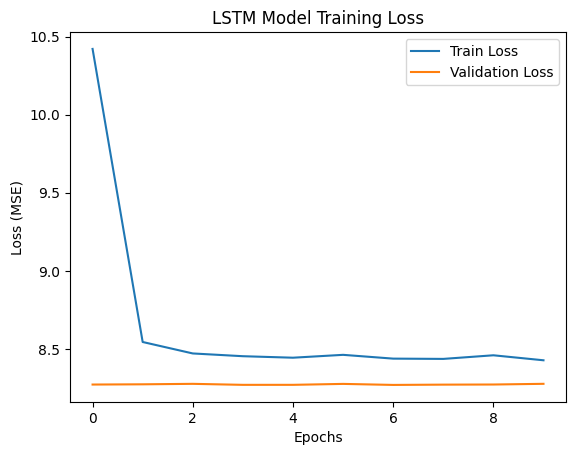

In [12]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('LSTM Model Training Loss')
plt.legend()
plt.show()


In [13]:
y_pred = model.predict(X_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


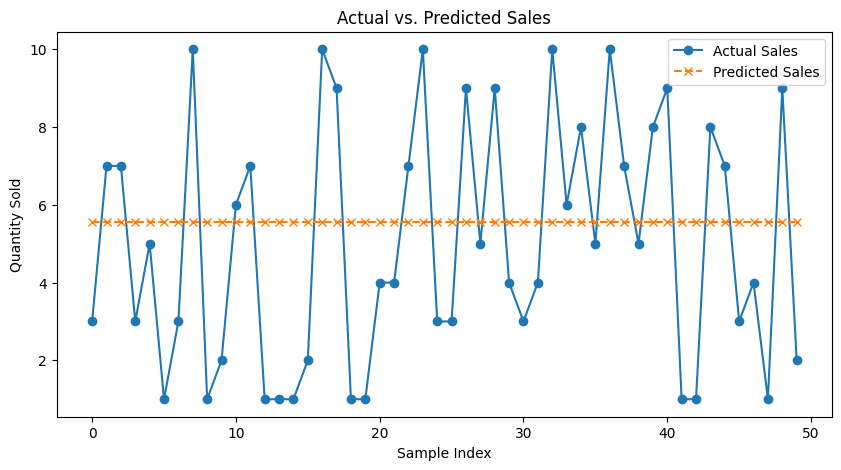

In [14]:
import matplotlib.pyplot as plt

# Plot first 50 actual vs. predicted values
plt.figure(figsize=(10, 5))
plt.plot(y_test[:50], label="Actual Sales", marker='o')
plt.plot(y_pred[:50], label="Predicted Sales", marker='x', linestyle='dashed')
plt.xlabel("Sample Index")
plt.ylabel("Quantity Sold")
plt.title("Actual vs. Predicted Sales")
plt.legend()
plt.show()


In [15]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Model RMSE: {rmse:.2f}")


Model RMSE: 2.88


In [16]:
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.models import Sequential

# Initialize the enhanced model
model = Sequential()

# First LSTM layer (with return_sequences=True for stacking)
model.add(LSTM(units=100, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))

# Second LSTM layer
model.add(LSTM(units=75, return_sequences=True))
model.add(Dropout(0.2))

# Third LSTM layer (final layer before output)
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

# Output layer
model.add(Dense(units=1))

# Compile model
model.compile(optimizer='adam', loss='mean_squared_error')

# Display summary
model.summary()


c:\Users\priks\anaconda3\envs\health\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 1, 100)         │        41,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1, 100)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 1, 75)          │        52,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 50)             │        25,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119,651 (467.39 KB)

 Trainable params: 119,651 (467.39 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
df['Month'] = pd.to_datetime(df['Dispatch Date']).dt.month  # Extract month
features = ['Price', 'RAM', 'ROM', 'Month'] + [col for col in df.columns if col.startswith('Brand_') or col.startswith('Processor Specification_')]

X = df[features].values.astype(np.float32)  # Ensure all numerical
y = df['Quantity Sold'].values.astype(np.float32)

X = np.reshape(X, (X.shape[0], 1, X.shape[1]))  # Reshape for LSTM input


In [18]:
history = model.fit(X_train, y_train, epochs=20, batch_size=64, validation_data=(X_test, y_test))


Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 13.9483 - val_loss: 8.2876
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 8.4826 - val_loss: 8.3003
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 8.4796 - val_loss: 8.3161
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 8.5631 - val_loss: 8.2738
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 8.4918 - val_loss: 8.3567
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 8.4924 - val_loss: 8.2714
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 8.4780 - val_loss: 8.2819
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 8.4537 - val_loss: 8.2721
Epoch 9/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 8.4199 - val_loss: 8.2749
Epoch 10/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 8.4741 - val_loss: 8.2729
Epoch 11/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 8.4863 - val_loss: 8.2888
Epoch 12/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/ste

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


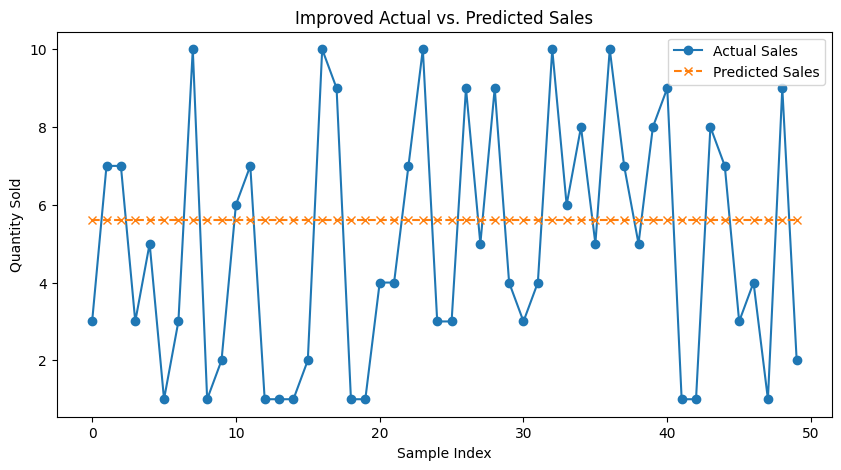

In [19]:
y_pred = model.predict(X_test)

plt.figure(figsize=(10, 5))
plt.plot(y_test[:50], label="Actual Sales", marker='o')
plt.plot(y_pred[:50], label="Predicted Sales", marker='x', linestyle='dashed')
plt.xlabel("Sample Index")
plt.ylabel("Quantity Sold")
plt.title("Improved Actual vs. Predicted Sales")
plt.legend()
plt.show()


In [20]:
from tensorflow.keras.optimizers import Adam

# Recompile model with a smaller learning rate
optimizer = Adam(learning_rate=0.001)  # Lower learning rate improves stability
model.compile(optimizer=optimizer, loss='mean_squared_error')

# Increase epochs and reduce batch size slightly for finer training
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 8.5138 - val_loss: 8.2954
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 8.4668 - val_loss: 8.2795
Epoch 3/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 8.5036 - val_loss: 8.2700
Epoch 4/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 8.4151 - val_loss: 8.2817
Epoch 5/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 8.3940 - val_loss: 8.2713
Epoch 6/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 8.4218 - val_loss: 8.2863
Epoch 7/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 8.4423 - val_loss: 8.2855
Epoch 8/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 8.4360 - val_loss: 8.2738
Epoch 9/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 8.4063 - val_loss: 8.2988
Epoch 10/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 8.4156 - val_loss: 8.2692
Epoch 11/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 8.3854 - val_loss: 8.2718
Epoch 12/50
1250/1250 ━━━━━━━━

In [22]:
df['Weekday'] = pd.to_datetime(df['Dispatch Date']).dt.dayofweek  # Extract weekday trends
df['Month'] = pd.to_datetime(df['Dispatch Date']).dt.month  # Capture seasonal effects

feature_columns += ['Weekday', 'Month']  # Add new time-based trends

X = df[feature_columns].values.astype(np.float32)
y = df['Quantity Sold'].values.astype(np.float32)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


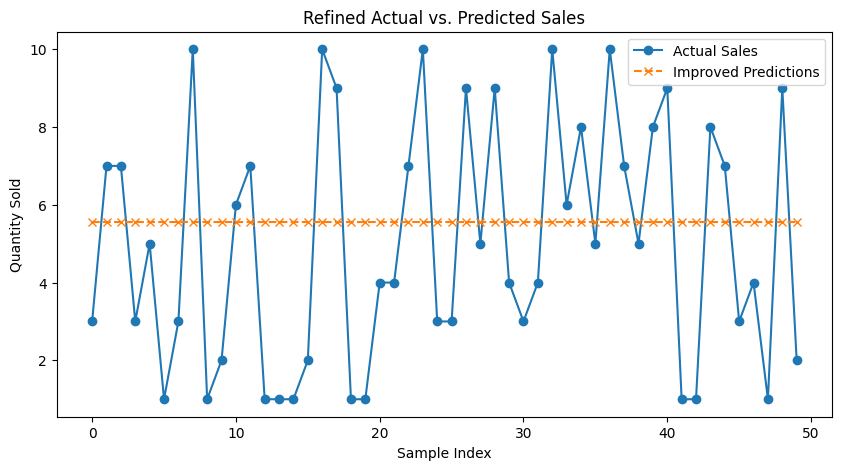

In [23]:
y_pred = model.predict(X_test)

plt.figure(figsize=(10, 5))
plt.plot(y_test[:50], label="Actual Sales", marker='o')
plt.plot(y_pred[:50], label="Improved Predictions", marker='x', linestyle='dashed')
plt.xlabel("Sample Index")
plt.ylabel("Quantity Sold")
plt.title("Refined Actual vs. Predicted Sales")
plt.legend()
plt.show()


In [24]:
df['Quantity Sold_Lag1'] = df['Quantity Sold'].shift(1)  # Previous day sales
df['Quantity Sold_Lag2'] = df['Quantity Sold'].shift(2)  # Two days ago sales

df.fillna(0, inplace=True)  # Handle missing values after shifting


In [26]:
print("Shape of X_train:", X_train.shape)  # Expected format: (samples, time steps, features)


Shape of X_train: (40000, 1, 3)


In [27]:
import numpy as np

X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))  
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))

print("Reshaped X_train:", X_train.shape)


Reshaped X_train: (40000, 1, 3)


In [28]:
model.add(LSTM(units=150, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))


ValueError: Input 0 of layer "lstm_5" is incompatible with the layer: expected ndim=3, found ndim=2. Full shape received: (None, 1)